# Generate image

In [ ]:
from PIL import Image, ImageDraw, ImageFont
import math

# --- Configurações ---
# Lista de tuplas: (caminho_para_imagem, rotulo)
# Certifique-se de que a ordem aqui corresponda à ordem desejada na grade.
# Adapte esta lista com seus próprios nomes de arquivo e rótulos.
images_with_labels = [
    (r"..\quadro-de-imagens\Original.jpg", 'Original'),
    (r"..\quadro-de-imagens\Brightness.jpg", 'Brightness'),
    (r"..\quadro-de-imagens\Contrast.jpg", 'Contrast'),
    (r"..\quadro-de-imagens\Defocus Blur.jpg", 'Defocus Blur'),
    (r"..\quadro-de-imagens\Elastic.jpg", 'Elastic'), 
    (r"..\quadro-de-imagens\Fog.jpg", 'Fog'),
    (r"..\quadro-de-imagens\Frost.jpg", 'Frost'),
    (r"..\quadro-de-imagens\Gaussian Blur.jpg", 'Gaussian Blur'),
    (r"..\quadro-de-imagens\Gaussian Noise.jpg", 'Gaussian Noise'),
    (r"..\quadro-de-imagens\Glass Blur.jpg", 'Glass Blur'),
    (r"..\quadro-de-imagens\Impulse Noise.jpg", 'Impulse Noise'),
    (r"..\quadro-de-imagens\JPEG.jpg", 'JPEG'),
    (r"..\quadro-de-imagens\Motion Blur.jpg", 'Motion Blur'),
    (r"..\quadro-de-imagens\Pixelate.jpg", 'Pixelate'),
    (r"..\quadro-de-imagens\Saturate.jpg", 'Saturate'),
    (r"..\quadro-de-imagens\Shot Noise.jpg", 'Shot Noise'),
    (r"..\quadro-de-imagens\Snow.jpg", 'Snow'),
    (r"..\quadro-de-imagens\Spatter.jpg", 'Spatter'),
    (r"..\quadro-de-imagens\Speckle Noise.jpg", 'Speckle Noise'),
    (r"..\quadro-de-imagens\Zoom Blur.jpg", 'Zoom Blur')
]


# Número de colunas desejado na grade (exemplo tem 5 colunas)
num_cols = 5
# Calcula o número de linhas necessário
num_rows = math.ceil(len(images_with_labels) / num_cols)

# Espaçamento entre as imagens e rótulos (em pixels)
padding = 10
label_height = 40 # Espaço reservado para o rótulo acima de cada imagem

# Caminho para salvar a imagem final
output_filename = 'quadro_de_efeitos.png'

# --- Processamento ---

# Carrega a primeira imagem para obter as dimensões (assumindo que todas têm tamanho semelhante)
try:
    with Image.open(images_with_labels[0][0]) as img:
        img_width, img_height = img.size
except IndexError:
    print("Erro: A lista 'images_with_labels' está vazia.")
    exit()
except FileNotFoundError:
    print(f"Erro: Imagem não encontrada em {images_with_labels[0][0]}")
    exit()


# Calcula as dimensões da imagem final
grid_width = num_cols * img_width + (num_cols - 1) * padding
grid_height = num_rows * (img_height + label_height) + (num_rows - 1) * padding

# Cria uma nova imagem em branco (fundo branco)
final_img = Image.new('RGB', (grid_width, grid_height), color='white')
draw = ImageDraw.Draw(final_img)

# Tenta carregar uma fonte (ajuste o caminho se necessário)
try:
    font = ImageFont.truetype("arial.ttf", 20)
except IOError:
    # Se a fonte arial.ttf não for encontrada, usa a fonte padrão da Pillow
    font = ImageFont.load_default()
    print("Aviso: Fonte 'arial.ttf' não encontrada. Usando fonte padrão.")


# Posiciona as imagens e adiciona os rótulos
for i, (image_path, label) in enumerate(images_with_labels):
    row = i // num_cols
    col = i % num_cols

    # Carrega a imagem individual
    try:
        img = Image.open(image_path)
    except FileNotFoundError:
        print(f"Erro: Imagem não encontrada em {image_path}. Pulando...")
        continue # Pula para a próxima imagem

    # Calcula a posição onde a imagem será colada
    x_offset = col * (img_width + padding)
    y_offset = row * (img_height + label_height) + label_height # Adiciona espaço para o rótulo

    # Cola a imagem na posição calculada
    final_img.paste(img, (x_offset, y_offset))

    # Calcula a posição onde o rótulo será desenhado (centralizado acima da imagem)
    # text_width, text_height = draw.textsize(label, font=font)
    # Obtém a caixa delimitadora do texto
    bbox = draw.textbbox((0, 0), label, font=font)
    text_width = bbox[2] - bbox[0]  # right - left = largura
    text_height = bbox[3] - bbox[1] # bottom - top = altura
    text_x = x_offset + (img_width - text_width) // 2
    text_y = row * (img_height + label_height) + (label_height - text_height) // 2 # Centraliza verticalmente no espaço do rótulo

    # Desenha o rótulo na imagem final (preto)
    draw.text((text_x, text_y), label, fill=(0, 0, 0), font=font)

    # Fecha a imagem individual para liberar memória
    img.close()

# Salva a imagem final
final_img.save(output_filename)

print(f"Quadro criado com sucesso: {output_filename}")

Quadro criado com sucesso: quadro_de_efeitos.png


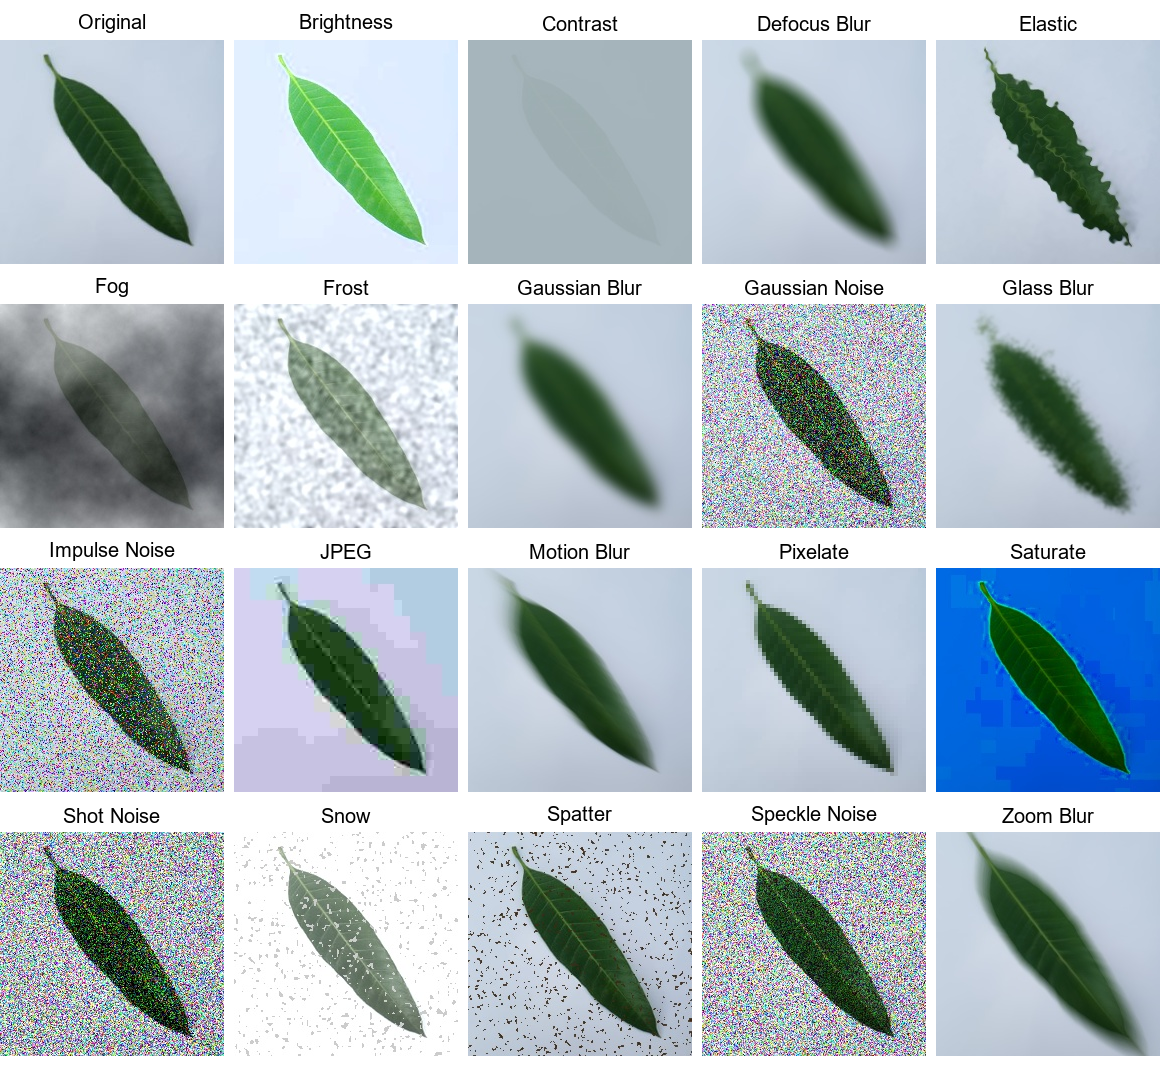

In [11]:
final_img